In [1]:
import warnings

In [3]:
warnings.filterwarnings("ignore")

In [5]:
import pandas as pd

In [7]:
import numpy as np

In [9]:
from sklearn.datasets import load_iris

In [11]:
from sklearn.preprocessing import StandardScaler

In [13]:
raw_iris = load_iris()

In [15]:
features = raw_iris.feature_names

In [17]:
X_raw = raw_iris.data

In [19]:
y_true = raw_iris.target

In [21]:
scaler = StandardScaler()

In [23]:
X_scaled = scaler.fit_transform(X_raw)

In [25]:
iris_df = pd.DataFrame(data=X_scaled, columns=features)

In [33]:
iris_df['species_id'] = y_true

In [35]:
species_map = {i: name for i, name in enumerate(raw_iris.target_names)}

In [37]:
iris_df['species_name'] = iris_df['species_id'].map(species_map)


In [39]:
print("Standardized dataset dimensions:", X_scaled.shape)
print("\nFirst 3 rows of standardized dataset:")
print(iris_df.head(3))

Standardized dataset dimensions: (150, 4)

First 3 rows of standardized dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   

   species_id species_name  
0           0       setosa  
1           0       setosa  
2           0       setosa  


In [41]:
cov_matrix = np.cov(X_scaled.T)

In [43]:
print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


In [45]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

In [47]:
print("\nEigenvalues (Variance components):\n", eigenvalues)
print("\nEigenvectors (Principal Axes):\n", eigenvectors)


Eigenvalues (Variance components):
 [2.93808505 0.9201649  0.14774182 0.02085386]

Eigenvectors (Principal Axes):
 [[ 0.52106591 -0.37741762 -0.71956635  0.26128628]
 [-0.26934744 -0.92329566  0.24438178 -0.12350962]
 [ 0.5804131  -0.02449161  0.14212637 -0.80144925]
 [ 0.56485654 -0.06694199  0.63427274  0.52359713]]


In [49]:
from sklearn.decomposition import PCA

In [51]:
pca_model = PCA(n_components=2, random_state=42)

In [53]:
X_pca = pca_model.fit_transform(X_scaled)

In [55]:
pca_df = pd.DataFrame(data=X_pca, columns=['PC_1', 'PC2'])

In [57]:
pca_df['species_name'] = iris_df['species_name']

In [59]:
print("Transformed PCA space dimensions:", X_pca.shape)
print("\nFirst 3 projected coordinates:")
print(pca_df.head(3))

Transformed PCA space dimensions: (150, 2)

First 3 projected coordinates:
       PC_1       PC2 species_name
0 -2.264703  0.480027       setosa
1 -2.080961 -0.674134       setosa
2 -2.364229 -0.341908       setosa


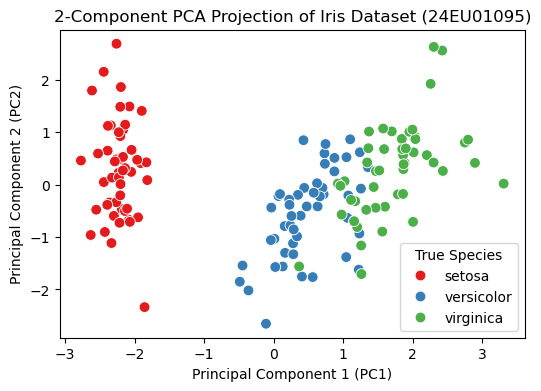

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.scatterplot(data=pca_df, x='PC_1', y='PC2', hue='species_name', palette='Set1', s=60)
plt.title("2-Component PCA Projection of Iris Dataset (24EU01095)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend(title='True Species')
plt.show()

In [63]:
explained_variance = pca_model.explained_variance_ratio_

In [65]:
cumulative_variance = np.sum(explained_variance)

In [67]:
print("Explained Variance per Component:")
for i, var in enumerate(explained_variance):
    print(f"  PC{i+1}: {var*100:.2f}%")

print(f"\nTotal Cumulative Variance Retained by 2 Components: {cumulative_variance*100:.2f}%")

Explained Variance per Component:
  PC1: 72.96%
  PC2: 22.85%

Total Cumulative Variance Retained by 2 Components: 95.81%


In [69]:
import numpy as np

In [71]:
import pandas as pd

In [73]:
import matplotlib.pyplot as plt

In [75]:
from sklearn.datasets import load_iris

In [77]:
from sklearn.model_selection import train_test_split

In [79]:
from sklearn.preprocessing import StandardScaler

In [81]:
from sklearn.decomposition import PCA

In [83]:
from sklearn.linear_model import LogisticRegression

In [85]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [87]:
iris = load_iris()

In [89]:
X = iris.data   

In [91]:
y = iris.target   

In [93]:
feature_names = iris.feature_names

In [95]:
target_names = iris.target_names

In [97]:
print("Dataset Shape:", X.shape)
print("Features:", feature_names)
print("Classes:", target_names)

Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [101]:
scaler = StandardScaler()

In [103]:
X_train_scaled = scaler.fit_transform(X_train)

In [105]:
X_test_scaled = scaler.transform(X_test)

In [107]:
print("\n========================================")
print("CLASSIFICATION WITHOUT PCA")
print("========================================")

model_without_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_without_pca.fit(
    X_train_scaled,
    y_train
)

y_pred_without_pca = model_without_pca.predict(
    X_test_scaled
)

accuracy_without_pca = accuracy_score(
    y_test,
    y_pred_without_pca
)

print("Accuracy without PCA:",
      accuracy_without_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_without_pca,
        target_names=target_names
    )
)


CLASSIFICATION WITHOUT PCA
Accuracy without PCA: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [109]:
print("\n========================================")
print("CLASSIFICATION WITH PCA")
print("========================================")

pca = PCA(
    n_components=2
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print("Explained Variance Ratio:",
      pca.explained_variance_ratio_)

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

model_with_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model_with_pca.fit(
    X_train_pca,
    y_train
)

y_pred_with_pca = model_with_pca.predict(
    X_test_pca
)

accuracy_with_pca = accuracy_score(
    y_test,
    y_pred_with_pca
)

print("Accuracy with PCA:",
      accuracy_with_pca)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_with_pca,
        target_names=target_names
    )
)


CLASSIFICATION WITH PCA
Explained Variance Ratio: [0.72677234 0.23066667]
Total Explained Variance: 0.9574390106545367
Accuracy with PCA: 0.9

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [111]:
print("\n========================================")
print("COMPARISON")
print("========================================")

comparison = pd.DataFrame({
    "Method": [
        "Without PCA",
        "With PCA"
    ],
    "Number of Features": [
        X_train_scaled.shape[1],
        X_train_pca.shape[1]
    ],
    "Accuracy": [
        accuracy_without_pca,
        accuracy_with_pca
    ]
})

print(comparison)


COMPARISON
        Method  Number of Features  Accuracy
0  Without PCA                   4  0.933333
1     With PCA                   2  0.900000


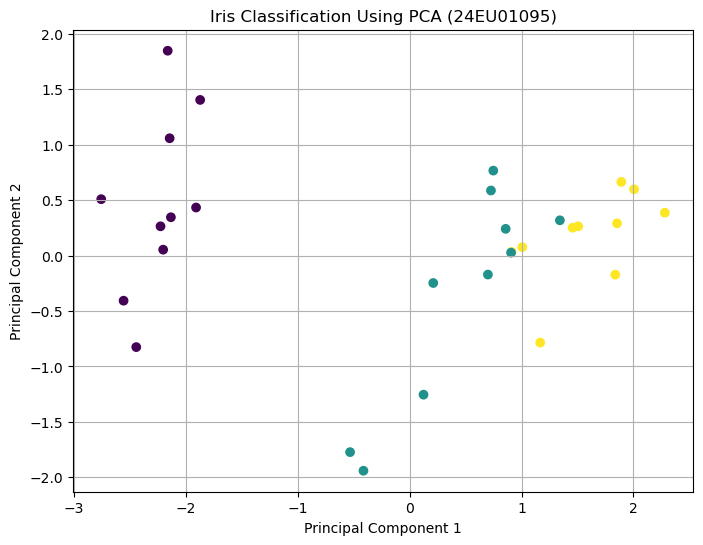

In [113]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Classification Using PCA (24EU01095)")
plt.grid()

plt.show()